In [1]:
import pandas as pd
import numpy as np

# NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv("BitcoinMining.csv")

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.366076e+09,201,self.BitcoinMining,1cfk7y,BEGINNERS GUIDE: Don't use guiminer [Please up...,purelithium,231,30,112,http://www.reddit.com/r/BitcoinMining/comments...,...,False,self,t5_2skbb,False,NaN,NaN,True,t3_1cfk7y,http://www.reddit.com/r/BitcoinMining/comments...,NaN
1,1.366197e+09,119,i.imgur.com,1ciy6p,"New to this, what kind of hash rate do you thi...",ripshy,164,45,19,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://b.thumbs.redditmedia.com/Inm0_Bd6M_JJap...,t5_2skbb,False,NaN,NaN,False,t3_1ciy6p,http://i.imgur.com/eddeeIA.jpg,NaN
2,1.369374e+09,112,imgur.com,1eyexd,Finally,effortninja,119,7,74,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://b.thumbs.redditmedia.com/v-7Q-1xEbNVgPZ...,t5_2skbb,False,NaN,NaN,False,t3_1eyexd,http://imgur.com/vHr1Upy,NaN
3,1.368422e+09,86,i.imgur.com,1e88zr,"My very first mining rig, made ~2 years ago to...",GigaByteCoin,96,10,22,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://d.thumbs.redditmedia.com/wMhhAI5WMVbEdP...,t5_2skbb,False,NaN,NaN,False,t3_1e88zr,http://i.imgur.com/wt8gPM1.jpg,moderator
4,1.366146e+09,85,i.imgur.com,1chit0,What is the estimated hashrate for this rig? (...,CallinInstead,94,9,24,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://e.thumbs.redditmedia.com/fQZzeJzSQNYdyE...,t5_2skbb,False,NaN,NaN,False,t3_1chit0,http://i.imgur.com/xvE6YHS.jpg,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  979 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                720 non-null    str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    text = str(text).lower()
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    words = text.split()
    
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

In [6]:
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.366076e+09,201,self.BitcoinMining,1cfk7y,BEGINNERS GUIDE: Don't use guiminer [Please up...,purelithium,231,30,112,http://www.reddit.com/r/BitcoinMining/comments...,...,False,self,t5_2skbb,False,NaN,NaN,True,t3_1cfk7y,http://www.reddit.com/r/BitcoinMining/comments...,NaN
1,1.366197e+09,119,i.imgur.com,1ciy6p,"New to this, what kind of hash rate do you thi...",ripshy,164,45,19,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://b.thumbs.redditmedia.com/Inm0_Bd6M_JJap...,t5_2skbb,False,NaN,NaN,False,t3_1ciy6p,http://i.imgur.com/eddeeIA.jpg,NaN
2,1.369374e+09,112,imgur.com,1eyexd,Finally,effortninja,119,7,74,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://b.thumbs.redditmedia.com/v-7Q-1xEbNVgPZ...,t5_2skbb,False,NaN,NaN,False,t3_1eyexd,http://imgur.com/vHr1Upy,NaN
3,1.368422e+09,86,i.imgur.com,1e88zr,"My very first mining rig, made ~2 years ago to...",GigaByteCoin,96,10,22,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://d.thumbs.redditmedia.com/wMhhAI5WMVbEdP...,t5_2skbb,False,NaN,NaN,False,t3_1e88zr,http://i.imgur.com/wt8gPM1.jpg,moderator
4,1.366146e+09,85,i.imgur.com,1chit0,What is the estimated hashrate for this rig? (...,CallinInstead,94,9,24,http://www.reddit.com/r/BitcoinMining/comments...,...,False,http://e.thumbs.redditmedia.com/fQZzeJzSQNYdyE...,t5_2skbb,False,NaN,NaN,False,t3_1chit0,http://i.imgur.com/xvE6YHS.jpg,NaN


In [8]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [9]:
list(df.columns)

['created_utc',
 'score',
 'domain',
 'id',
 'title',
 'author',
 'ups',
 'downs',
 'num_comments',
 'permalink',
 'selftext',
 'link_flair_text',
 'over_18',
 'thumbnail',
 'subreddit_id',
 'edited',
 'link_flair_css_class',
 'author_flair_css_class',
 'is_self',
 'name',
 'url',
 'distinguished']

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [13]:
y_pred = rf.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



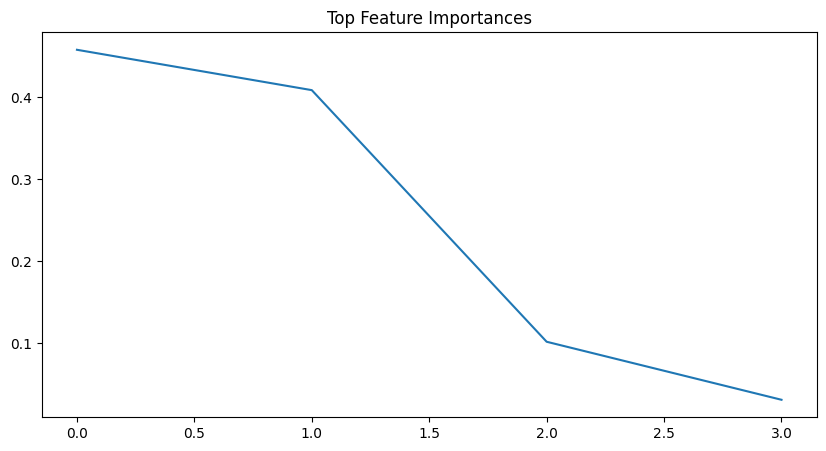

In [15]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.plot(sorted(importance, reverse=True)[:20])
plt.title("Top Feature Importances")
plt.show()